Загружу данные и посмотрю как они выглядят

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('retail_sales_mock_data.csv',
                 index_col = 'Date', parse_dates = True)
df.head()

,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


Статистическое описание

Видно, что продажи ежемесячные

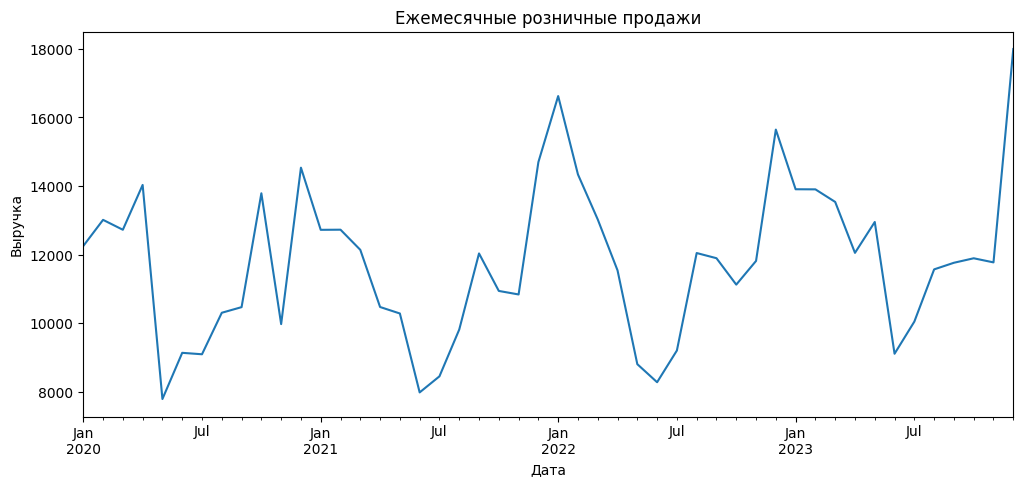

In [10]:
ax = df['SalesAmount'].plot(figsize = (12, 5), legend = None)
ax.set(title = 'Ежемесячные розничные продажи',
       xlabel = 'Дата',
       ylabel = 'Выручка');



Прослеживается сезонность, так как в январе каждого года видны характерные пики и спады в летнее время. Очень сильно бросается в глаза резкий рост выручки в декабре 2023 года, возможно были предновогодние акции или праздничная закупка перед новым годом. Выраженного тренда не наблюдается, так как выручка находится плюс минус на одном уровне

In [6]:
df['SalesAmount'].describe().round(2)

count       48.00
mean     11768.54
std       2257.54
min       7783.00
25%      10219.75
50%      11851.00
75%      13014.00
max      17996.00
Name: SalesAmount, dtype: float64

Из таблички видно, что датасет содержит 48 строк, я решила открыть его полностью и увидела, что данные ежемесячные за 4 года (гранулярность - месяц). Средняя выручка составляет 11 769 рублей. При этом разброс значений большой, так как стандартное отклонение 2258 рублей. Медиана составила 11 851 руб и близка к среднему, скорее всего не будет сильной асимметрии в распределении

межквартильный размах имеет формулу IQR = Q3 − Q1 = 13 014 - 10 219 = 2 794 руб, получила диапазон в котором находится средние 50% всех значений

Посчитаю границы выбросов:

Lower Bound = Q1 − 1.5×IQR = 10 220 − 1.5 × 2 794 = 6 029 руб

Upper Bound = Q3 + 1.5×IQR = 13 014 + 1.5 × 2 794 = 17 205 руб

Следовательно декабрь 2023 с выручкой приблизительно 18 000 руб является выбросом, так как выше верхней границы

In [9]:
print(f'Пропущенные значения: {df["SalesAmount"].isna().sum()}')


Пропущенные значения: 0


Пропущенных значений в данных нет, поэтому обработка данных не нужна

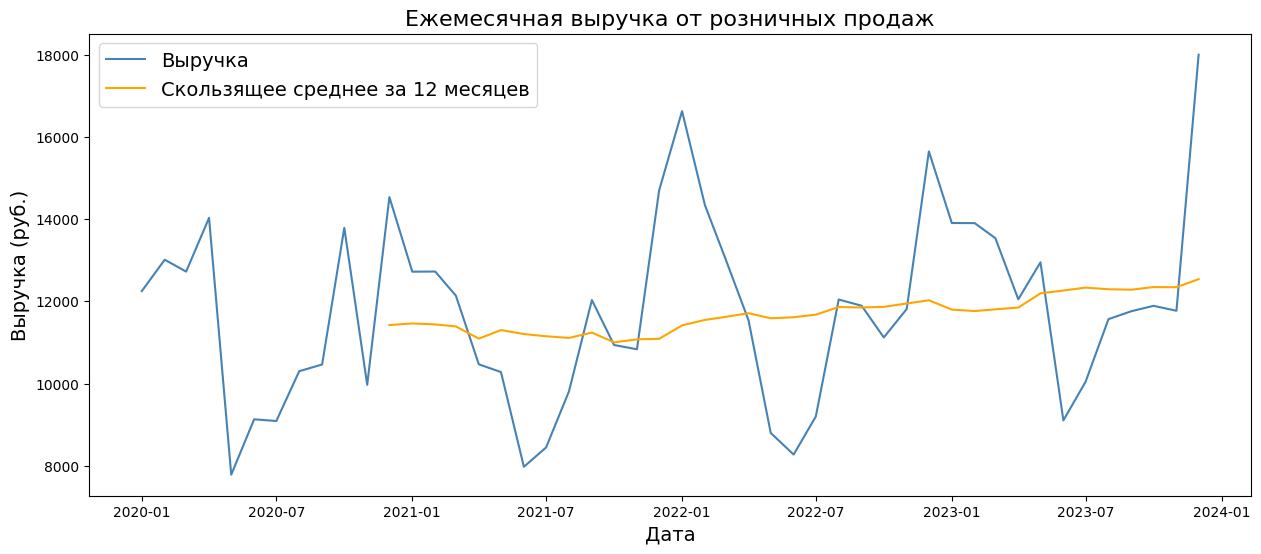

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(df['SalesAmount'], label='Выручка', color='steelblue')
plt.plot(df['SalesAmount'].rolling(window=12).mean(), label='Скользящее среднее за 12 месяцев', color='orange')

plt.legend(title='', loc='upper left', fontsize=14)

plt.xlabel('Дата', fontsize=14)
plt.ylabel('Выручка (руб.)', fontsize=14)
plt.title('Ежемесячная выручка от розничных продаж', fontsize=16)

plt.show()


Здесь уже тренд есть, но очень слабый. Средняя выручка выросла приблизительно с 11 000 до 12 500 рублей. На предыдущем графике тренд был не заметен, видимо из-за сильных сезонных колебаний

Можно сделать вывод, что ряд является нестационарным, так как есть явная сезонность и слабый восходящий тренд

Гистограмма

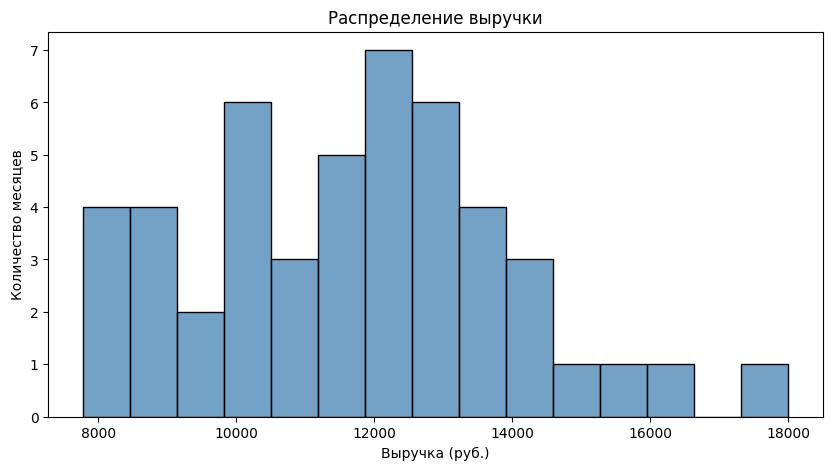

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df['SalesAmount'], bins=15, color='steelblue')
plt.title('Распределение выручки')
plt.xlabel('Выручка (руб.)')
plt.ylabel('Количество месяцев')
plt.show()

По гистограмме видно, что большинство месяцев выручка находилась в диапазоне от 10 000 до 13 000 руб. Один месяц с выручкой около 18 000 руб

Диаграмма размаха

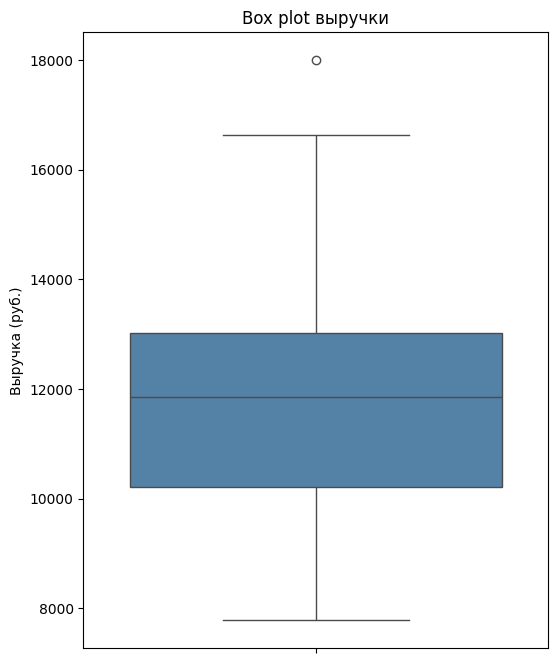

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 8))
sns.boxplot(y=df['SalesAmount'], color='steelblue')
plt.title('Box plot выручки')
plt.ylabel('Выручка (руб.)')
plt.show()

Синий прямоугольник охватывает средние 50% данных от 10 000 до 13 000. Линия внутри прямоугольника как раз медиана, в табличке чуть выше она как раз составила 11 850 рублей. Усы показывают нормальный диапазон значений. А кружок выше верхнего уса указывает на единичный выброс